# Next-Word Prediction: LSTM

Trains and evaluates an **LSTM** model on prepared windows and held-out test sentences.

**Architecture:** `Embedding → LSTM → Dropout → Dense → Softmax`

The LSTM uses **forget, input, and output gates** with a separate cell state, allowing it to retain information across many steps.

**Metrics:** **Top-1**, **Top-5 accuracy**, and **Perplexity** (`exp(cross-entropy)`). Lower perplexity means the model is less surprised by the real next word.


## 1. Setup

In [1]:
%matplotlib inline
import os
import sys
sys.path.append(os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import config

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print(f"Epochs={config.EPOCHS}  Units={config.UNITS}  EmbedDim={config.EMBED_DIM}  BatchSize={config.BATCH_SIZE}  SeqLen={config.SEQ_LEN}")

TensorFlow: 2.21.0
Epochs=8  Units=64  EmbedDim=64  BatchSize=256  SeqLen=5


In [2]:
from scripts.build_corpus import build_corpus

sources = {
    name: config.RAW_DIR / name
    for name in ("en_US.blogs.txt", "en_US.news.txt", "en_US.twitter.txt")
}
if config.DEFAULT_CORPUS.exists():
    print(f"Corpus already built: {config.DEFAULT_CORPUS}  (delete it to rebuild)")
else:
    build_corpus(sources, config.DEFAULT_CORPUS, lines_per_source=config.CORPUS_LINES_PER_SOURCE)

Corpus already built: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\data\raw\corpus.txt  (delete it to rebuild)


## 2. Train

`src.train.train` is the same code path as `python -m src.train --model lstm`. It uses early stopping on validation loss, halves the learning rate on plateaus, saves the best checkpoint to `models/lstm.keras`, and appends results to `outputs/metrics.json`.

In [3]:
from src.train import train

result = train(
    "lstm",
    config.DEFAULT_CORPUS,
    verbose=2,
)

Data: {"vocab_size": 10000, "train_samples": 976755, "val_samples": 120778, "test_samples": 121282, "seq_len": 5}


Model: "next_word_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,024 (5.05 MB)

 Trainable params: 1,323,024 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3816/3816 - 182s - 48ms/step - loss: 6.5228 - top1_accuracy: 0.0979 - top5_accuracy: 0.2338 - val_loss: 6.0948 - val_top1_accuracy: 0.1265 - val_top5_accuracy: 0.2732 - learning_rate: 0.0010
Epoch 2/8
3816/3816 - 180s - 47ms/step - loss: 6.1097 - top1_accuracy: 0.1234 - top5_accuracy: 0.2713 - val_loss: 5.8890 - val_top1_accuracy: 0.1382 - val_top5_accuracy: 0.2949 - learning_rate: 0.0010
Epoch 3/8
3816/3816 - 180s - 47ms/step - loss: 5.9511 - top1_accuracy: 0.1319 - top5_accuracy: 0.2869 - val_loss: 5.7790 - val_top1_accuracy: 0.1460 - val_top5_accuracy: 0.3070 - learning_rate: 0.0010
Epoch 4/8
3816/3816 - 173s - 45ms/step - loss: 5.8563 - top1_accuracy: 0.1373 - top5_accuracy: 0.2958 - val_loss: 5.7132 - val_top1_accuracy: 0.1500 - val_top5_accuracy: 0.3142 - learning_rate: 0.0010
Epoch 5/8
3816/3816 - 162s - 42ms/step - loss: 5.7879 - top1_accuracy: 0.1408 - top5_accuracy: 0.3016 - val_loss: 5.6679 - val_top1_accuracy: 0.1536 - val_top5_accuracy: 0.3183 - learning_rate: 0.

## 3. Training curves

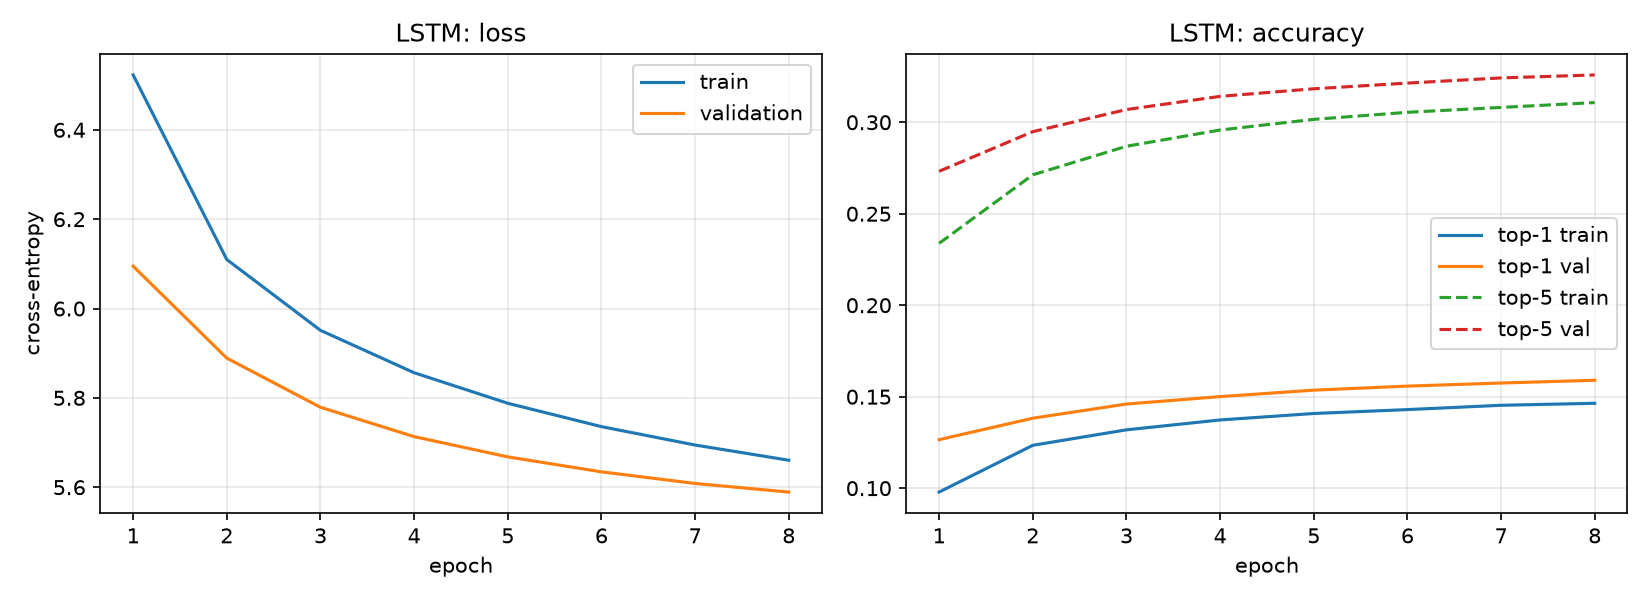

In [4]:
from IPython.display import Image, display

display(Image(filename=str(config.OUTPUTS_DIR / "lstm_training_curves.png")))

## 4. Test-set results

In [5]:
pd.Series({k: v for k, v in result.items() if k != "hyperparameters"})

model               lstm
parameters       1323024
top1_accuracy     0.1574
top5_accuracy     0.3281
test_loss         5.5832
perplexity        265.92
train_seconds     1388.6
epochs_run             8
best_epoch             8
dtype: object

## 5. Try it

Load the saved model exactly as the web app does.

In [6]:
from src.predict import Predictor

predictor = Predictor.load(config.MODELS_DIR / "lstm.keras", config.VOCAB_PATH)

for prompt in ["i want to go to the ", "it is a ", "holmes was ", "what do you "]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(f"{s['word']} ({s['probability']:.0%})" for s in top5))

'i want to go to the '     -> first (1%), new (1%), same (1%), world (1%), way (0%)
'it is a '                 -> good (4%), lot (3%), great (2%), little (2%), bit (2%)
'holmes was '              -> a (10%), the (4%), in (3%), not (3%), an (1%)
'what do you '             -> have (11%), want (5%), know (5%), get (4%), are (4%)


In [8]:
# Mid-word completion, like a keyboard: the last word is unfinished, so we complete it
for prompt in ["i want to g", "it was a very d"]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(s["word"] for s in top5))

'i want to g'              -> get, go, give, grow, gain
'it was a very d'          -> difficult, different, damn, disappointed, dark


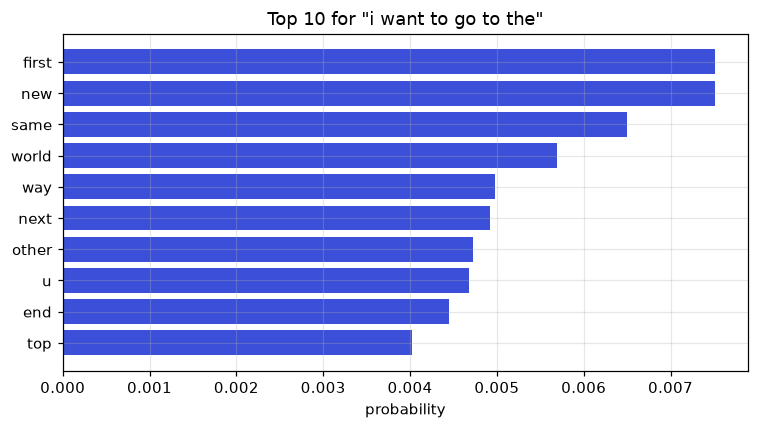

In [9]:
# Probability distribution behind the five suggestions (the last box in the sketch)

%matplotlib inline

prompt = "i want to go to the "
top = predictor.predict_next(prompt, k=10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([s["word"] for s in top][::-1], [s["probability"] for s in top][::-1], color="#3b4fd8")
ax.set(title=f'Top 10 for "{prompt.strip()}"', xlabel="probability")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "lstm_example_prediction.png")
plt.show()

Next: `04_gru.ipynb`.